In [97]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [98]:
data_path = r"C:\Users\Hakim.Ibrahim.AIRTELTIGO\Downloads\cr_loan2.csv"
credit_data = pd.read_csv(data_path)
credit_data.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [99]:
credit_data.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [100]:
credit_data.describe().round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,31686.00,32581.00,29465.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.79,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.14,6322.09,3.24,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.47,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


In [101]:
credit_data.describe(include='object')

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


In [102]:
for col in credit_data.columns:
    print(col)
    print(f'{credit_data[col].isna().sum()}\n')

person_age
0

person_income
0

person_home_ownership
0

person_emp_length
895

loan_intent
0

loan_grade
0

loan_amnt
0

loan_int_rate
3116

loan_status
0

loan_percent_income
0

cb_person_default_on_file
0

cb_person_cred_hist_length
0



In [103]:
credit_data['person_age'].idxmax()

81

In [104]:
credit_data.iloc[81,:]

person_age                        144
person_income                  250000
person_home_ownership            RENT
person_emp_length                 4.0
loan_intent                   VENTURE
loan_grade                          C
loan_amnt                        4800
loan_int_rate                   13.57
loan_status                         0
loan_percent_income              0.02
cb_person_default_on_file           N
cb_person_cred_hist_length          3
Name: 81, dtype: object

In [105]:
credit_data['person_emp_length'].idxmax()

0

In [106]:
credit_data.iloc[0,:]

person_age                          22
person_income                    59000
person_home_ownership             RENT
person_emp_length                123.0
loan_intent                   PERSONAL
loan_grade                           D
loan_amnt                        35000
loan_int_rate                    16.02
loan_status                          1
loan_percent_income               0.59
cb_person_default_on_file            Y
cb_person_cred_hist_length           3
Name: 0, dtype: object

In [107]:
#credit_data.groupby('person_emp_length')['person_emp_length'].count()
credit_data['person_emp_length'].value_counts(dropna = False)

person_emp_length
0.0      4105
2.0      3849
3.0      3456
5.0      2946
1.0      2915
4.0      2874
6.0      2666
7.0      2196
8.0      1687
9.0      1367
NaN       895
11.0      740
10.0      696
12.0      575
13.0      426
14.0      335
15.0      238
16.0      165
17.0      129
18.0      104
19.0       64
20.0       42
21.0       38
22.0       19
24.0       10
23.0       10
25.0        8
26.0        6
27.0        5
31.0        4
28.0        3
123.0       2
30.0        2
41.0        1
34.0        1
29.0        1
38.0        1
Name: count, dtype: int64

In [108]:
credit_data[credit_data['person_emp_length'].isna()]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
105,22,12600,MORTGAGE,NaN,PERSONAL,A,2000,5.42,1,0.16,N,4
222,24,185000,MORTGAGE,NaN,EDUCATION,B,35000,12.42,0,0.19,N,2
379,24,16800,MORTGAGE,NaN,DEBTCONSOLIDATION,A,3900,NaN,1,0.23,N,3
407,25,52000,RENT,NaN,PERSONAL,B,24000,10.74,1,0.46,N,2
408,22,17352,MORTGAGE,NaN,EDUCATION,C,2250,15.27,0,0.13,Y,3
...,...,...,...,...,...,...,...,...,...,...,...,...
32285,38,12000,OWN,NaN,EDUCATION,A,4800,7.29,1,0.40,N,12
32328,51,18408,RENT,NaN,PERSONAL,C,1000,14.65,1,0.05,Y,20
32360,70,39996,RENT,NaN,MEDICAL,C,3600,15.23,0,0.09,Y,19
32453,56,32400,RENT,NaN,MEDICAL,A,8575,7.51,0,0.26,N,18


In [109]:
no_interest_df = credit_data[credit_data['loan_int_rate'].isna()]
no_interest_df['loan_grade'].value_counts()


loan_grade
B    1056
A    1003
C     630
D     312
E      83
F      27
G       5
Name: count, dtype: int64

In [110]:
credit_data.groupby('loan_grade').agg({'loan_amnt':'mean', 'loan_int_rate':'mean'})#['loan_int_rate','loan_amount'].mean()

,loan_amnt,loan_int_rate
loan_grade,,
A,8539.273453,7.327651
B,9995.483686,10.995555
C,9213.862651,13.463542
D,10849.241589,15.361448
E,12915.845436,17.009455
F,14717.323651,18.609159
G,17195.703125,20.251525


In [111]:
credit_data.groupby('loan_grade').agg({'loan_amnt':'mean','loan_int_rate':'min'})

,loan_amnt,loan_int_rate
loan_grade,,
A,8539.273453,5.42
B,9995.483686,6.00
C,9213.862651,6.00
D,10849.241589,6.00
E,12915.845436,6.00
F,14717.323651,15.01
G,17195.703125,17.34


In [112]:
credit_data.groupby('loan_grade').agg({'loan_amnt':'mean', 'loan_int_rate':'max'})

,loan_amnt,loan_int_rate
loan_grade,,
A,8539.273453,9.63
B,9995.483686,12.69
C,9213.862651,16.11
D,10849.241589,18.49
E,12915.845436,20.69
F,14717.323651,22.06
G,17195.703125,23.22


In [113]:
credit_data[credit_data['person_emp_length'] > 41]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


In [114]:
credit_data.loc[
    credit_data['person_emp_length'] > (credit_data['person_age'] - 15),
    ['person_age', 'person_emp_length', 'loan_status', 'cb_person_default_on_file'] 
]

,person_age,person_emp_length,loan_status,cb_person_default_on_file
0,22,123.0,1,Y
210,21,123.0,0,N


In [115]:
credit_data.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [117]:
print(credit_data['loan_percent_income'].max())
print(credit_data['loan_percent_income'].min())

0.83
0.0


In [118]:
credit_data['loan_percent_income'].quantile([.25, .5 , .75, .95, .99])

0.25    0.09
0.50    0.15
0.75    0.23
0.95    0.38
0.99    0.50
Name: loan_percent_income, dtype: float64

In [120]:
credit_data['lpi_band'] = pd.cut(credit_data['loan_percent_income'], 
                                 bins = [0.00, 0.09, 0.15, 0.23, 0.38, 0.50, 0.83],
                                 labels = ['0.00-0.09', '0.09-0.15', '0.15-0.23','0.23-0.38', '0.38-0.50', '0.50-0.83'])

In [ ]:
credit_data.groupby('lpi_band', observed=)['loan_status'].mean()

C:\Users\Hakim.Ibrahim.AIRTELTIGO\AppData\Local\Temp\ipykernel_22396\33584862.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_data.groupby('lpi_band')['loan_status'].mean()


lpi_band
0.00-0.09    0.115522
0.09-0.15    0.128050
0.15-0.23    0.186315
0.23-0.38    0.403772
0.38-0.50    0.715441
0.50-0.83    0.786290
Name: loan_status, dtype: float64

In [122]:
summary = (
    credit_data
    .groupby("lpi_band")
    .agg(
        borrowers=("loan_status", "count"),
        defaults=("loan_status", "sum"),
        default_rate=("loan_status", "mean"),
        avg_income=("person_income", "mean"),
        avg_loan=("loan_amnt", "mean")
    )
)

summary

C:\Users\Hakim.Ibrahim.AIRTELTIGO\AppData\Local\Temp\ipykernel_22396\1110030179.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("lpi_band")


,borrowers,defaults,default_rate,avg_income,avg_loan
lpi_band,,,,,
0.00-0.09,8942,1033,0.115522,86170.373295,4970.224782
0.09-0.15,8239,1055,0.128050,68251.647045,8435.950965
0.15-0.23,7702,1435,0.186315,58514.652558,11184.013892
0.23-0.38,6204,2505,0.403772,47990.593488,14036.847195
0.38-0.50,1237,885,0.715441,38606.052546,16652.384802
0.50-0.83,248,195,0.786290,33277.713710,18651.713710


Text(0.5, 1.0, 'correlation of features')

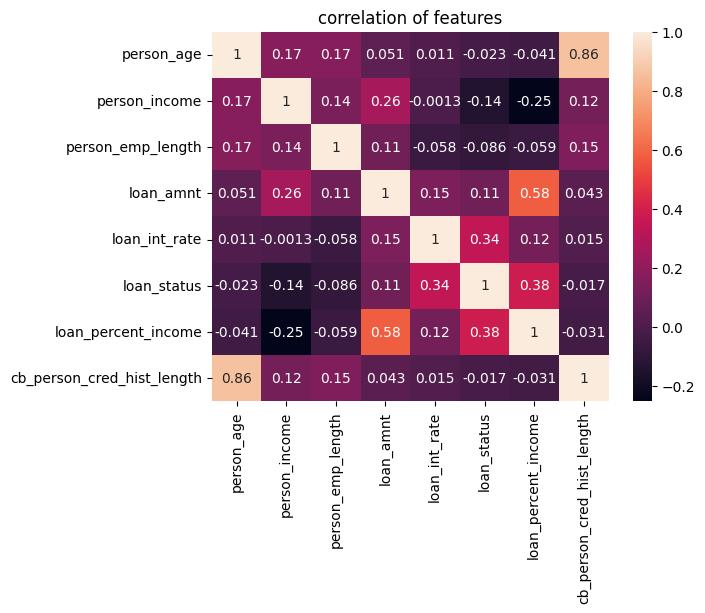

In [158]:
cor = credit_data.select_dtypes(include='number').corr()
sns.heatmap(cor, annot=True)
plt.title(r'correlation of features')

In [119]:
#Check for target imbalance
credit_data['loan_status'].value_counts(normalize= True)

loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64

In [123]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [124]:

from sklearn.base import BaseEstimator, TransformerMixin
class GroupMedianImputer(BaseEstimator, TransformerMixin):
    def __init__(self, group_col, target_col):
        self.group_col = group_col
        self.target_col = target_col
        self.group_medians_ = {}
        self.global_median_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        self.group_medians_ = X_df.groupby(self.group_col)[self.target_col].median().to_dict()
        self.global_median_ = X_df[self.target_col].median()
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        group_mapped_values = X_df[self.group_col].map(self.group_medians_)
        fallback_values = group_mapped_values.fillna(self.global_median_)
        X_df[self.target_col] = X_df[self.target_col].fillna(fallback_values)
        return X_df

    def get_feature_names_out(self, input_features=None):
        # Tells the pipeline that the output columns match the input columns exactly
        return np.array([self.group_col, self.target_col])



In [125]:
#The Group-Based Interest Rate Imputer & Grade Encoder ---
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

interest_and_grade_pipeline = Pipeline(steps=[
    ('group_imputer', GroupMedianImputer(group_col='loan_grade', target_col='loan_int_rate')),
    ('encode_and_scale', ColumnTransformer(transformers=[
        ('scale_interest', StandardScaler(), ['loan_int_rate']),
        ('ordinal_grade', OrdinalEncoder(categories=[grade_order]), ['loan_grade'])
    ]))
])

# --- Pure Numerical Features (Including Employment Length) ---
# This correctly treats years of employment as a number and replaces nulls with the median
numeric_pipeline = Pipeline(steps=[
    ('num_imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

# --- Track 3: Standard Categorical Features ---
categorical_pipeline = Pipeline(steps=[
    ('one_hot', OneHotEncoder(handle_unknown='ignore'))
])

# --- The Master Preprocessor ---
preprocessor = ColumnTransformer(
    transformers=[
        ('rates_and_grades', interest_and_grade_pipeline, ['loan_grade', 'loan_int_rate']),
        ('numeric_features', numeric_pipeline, ['person_age', 'person_income', 'person_emp_length', 'loan_amnt','loan_percent_income','cb_person_cred_hist_length']),
        ('categorical_features', categorical_pipeline, ['person_home_ownership','loan_intent','cb_person_default_on_file'])
    ])


In [126]:
credit_data = credit_data[
    credit_data['person_emp_length'] <= (credit_data['person_age'] - 15)
]
Y = credit_data['loan_status']
X = credit_data.drop(columns = ['loan_status'])
X.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'lpi_band'],
      dtype='object')

In [127]:
X_train, X_test,y_train, y_test = train_test_split(X,Y, test_size= .2,random_state= 42, stratify= Y)

In [128]:
models = {
      'logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
      'Random Forest' : RandomForestClassifier(random_state=42, class_weight='balanced'),
      'XGBoost': XGBClassifier(random_state = 42, eval_metric = 'logloss')
}
for name, model in models.items():
    clf_pipeline = Pipeline(
        steps = [
            ('preprocessors', preprocessor),
            ('classifier', model)
        ]
    )
    scores = cross_val_score(clf_pipeline, X_train,y_train, cv = 5, scoring = 'roc_auc')
    print(name)
    print(f"Mean AUC Score: {scores.mean():.4f}(+/-{scores.std():.4f})\n")

logistic Regression
Mean AUC Score: 0.8642(+/-0.0028)

Random Forest
Mean AUC Score: 0.9284(+/-0.0035)

XGBoost
Mean AUC Score: 0.9473(+/-0.0015)



In [129]:
from sklearn.model_selection import cross_validate
scoring_metrics = ['recall', 'precision', 'f1']
models = {
      'logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
      'Random Forest' : RandomForestClassifier(random_state=42, class_weight='balanced'),
      'XGBoost': XGBClassifier(random_state = 42, eval_metric = 'logloss')
}
for name, model in models.items():
    clf_pipeline = Pipeline(
        steps = [
            ('preprocessors', preprocessor),
            ('classifier', model)
        ]
    )
    cv_result = cross_validate(clf_pipeline, X_train,y_train, cv = 5, scoring = scoring_metrics)
    print(f'== {name} ==')
    print(f"Sensitivity: {cv_result['test_recall'].mean():.4f}")
    print(f"Precision: {cv_result['test_precision'].mean():.4f}")
    print(f"F1-score: {cv_result['test_f1'].mean():.4f}\n")


== logistic Regression ==
Sensitivity: 0.7800
Precision: 0.5102
F1-score: 0.6168

== Random Forest ==
Sensitivity: 0.7037
Precision: 0.9754
F1-score: 0.8175

== XGBoost ==
Sensitivity: 0.7396
Precision: 0.9559
F1-score: 0.8338



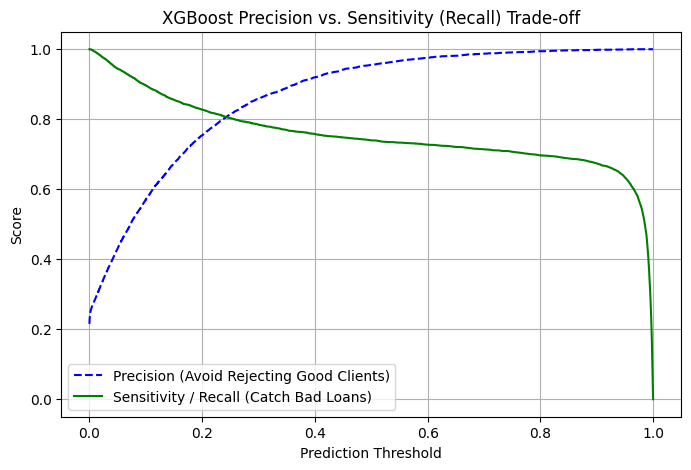

In [130]:

from sklearn.metrics import precision_recall_curve, f1_score
from sklearn.model_selection import cross_val_predict
# 1. Build your final XGBoost pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocessors', preprocessor),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
])

# 2. Get the raw probability scores for the positive class (Default)
# This returns an array of probabilities between 0.0 and 1.0
y_scores = cross_val_predict(xgb_pipeline, X_train, y_train, cv=5, method='predict_proba')[:, 1]

#Calculate precision, recall, and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

#Plot the relationship
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision (Avoid Rejecting Good Clients)')
plt.plot(thresholds, recalls[:-1], 'g-', label='Sensitivity / Recall (Catch Bad Loans)')
plt.xlabel('Prediction Threshold')
plt.ylabel('Score')
plt.title('XGBoost Precision vs. Sensitivity (Recall) Trade-off')
plt.legend(loc='best')
plt.grid(True)
plt.show()

['loan_int_rate', 'loan_grade', 'person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'cb_person_default_on_file_N', 'cb_person_default_on_file_Y']
[-0.15470607  1.04929076 -0.04365443  0.04195707 -0.00522407 -0.60543826
  1.31910223  0.0107426  -0.07168876  0.01539754 -1.69984125  0.54792916
  0.16553912 -0.55207616  0.31737365  0.0668128  -0.29716677 -0.90868594
 -0.55654817 -0.65165514]


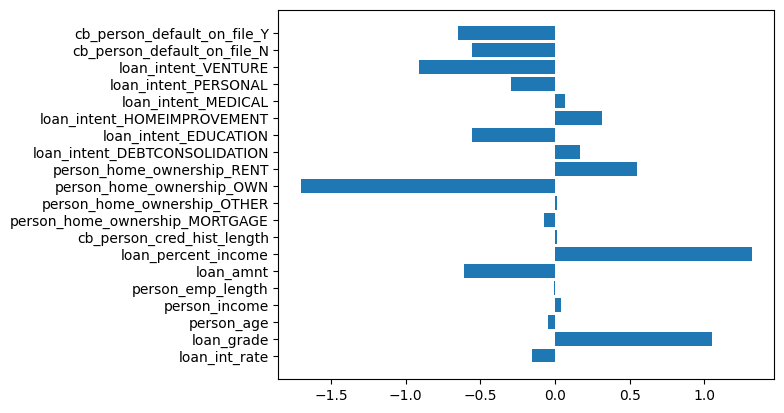

In [136]:
Logreg_pipeline = Pipeline(steps=[
    ('preprocessors', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])

Logreg_pipeline.fit(X_train,y_train)
feature_names = Logreg_pipeline.named_steps['preprocessors'].get_feature_names_out()
clean_feature_names = [name.split('__')[-1] for name in feature_names]
feature_importance = Logreg_pipeline.named_steps['classifier'].coef_[0]
#abs_coefficient = np.abs(feature_importance)
print(clean_feature_names)
print(feature_importance)
plt.barh(clean_feature_names, feature_importance)
plt.show()

['loan_int_rate', 'loan_grade', 'person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'cb_person_default_on_file_N', 'cb_person_default_on_file_Y']
[0.15470607 1.04929076 0.04365443 0.04195707 0.00522407 0.60543826
 1.31910223 0.0107426  0.07168876 0.01539754 1.69984125 0.54792916
 0.16553912 0.55207616 0.31737365 0.0668128  0.29716677 0.90868594
 0.55654817 0.65165514]


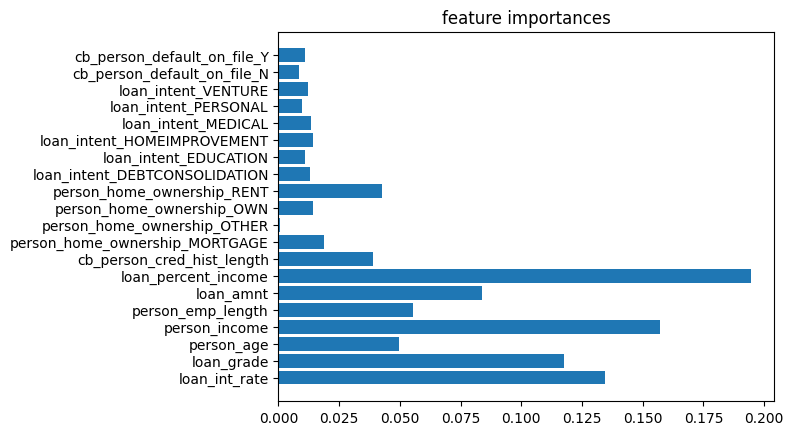

In [154]:
rf_pipeline = Pipeline(steps=[
    ('preprocessors', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

rf_pipeline.fit(X_train,y_train)
feature_names = rf_pipeline.named_steps['preprocessors'].get_feature_names_out()
clean_feature_names = [name.split('__')[-1] for name in feature_names]
feature_importance = rf_pipeline.named_steps['classifier'].feature_importances_
#abs_coefficient = np.abs(feature_importance)
print(clean_feature_names)
print(abs_coefficient)
plt.barh(clean_feature_names, feature_importance)
plt.title(r'feature importances')
plt.show()

In [144]:
xgb_pipeline.fit(X_train, y_train)
y_pred_pd = xgb_pipeline.predict_proba(X_test)[:, 1].round(2)
y_pred_pd
y_pred = (y_pred_pd>0.5).astype(int)

In [ ]:
print(y_pred_pd[0:10])
print(y_pred[0:10])
print(y_test[0:10])

[0.   0.   0.04 0.25 0.   0.02 0.01 0.98 0.02 0.02]
[0 0 0 0 0 0 0 1 0 0]
17437    0
26366    0
16141    0
16204    0
14140    0
8499     0
13983    0
18925    1
4931     0
16930    0
Name: loan_status, dtype: int64


In [150]:
y_test.value_counts()

loan_status
0    4972
1    1365
Name: count, dtype: int64

[[4920   52]
 [ 347 1018]]


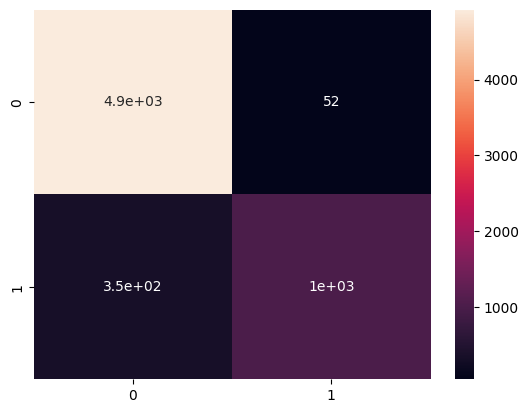

In [149]:
from sklearn.metrics import confusion_matrix
conf_mat = confusion_matrix(y_test, y_pred, labels=[0,1]).round(1)
print(conf_mat)
sns.heatmap(conf_mat, annot= True)
plt.show()

In [153]:
quantiles = np.quantile(y_pred_pd, [0.1, 0.20, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
quantiles

array([0.        , 0.        , 0.01      , 0.02      , 0.04      ,
       0.07      , 0.12      , 0.30000001, 0.99000001, 1.        ])

In [ ]:
100 80 , 60, 50